<a href="https://colab.research.google.com/github/Tanishqnarayan/AIML/blob/main/AIML_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes

# Load dataset
data = load_diabetes(as_frame=True)
df = data.frame

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:
# Calculate median target
median_target = df["target"].median()

print("Median target value:", median_target)

# Create binary classification target
df["class"] = (df["target"] >= median_target).astype(int)

print("\nClass distribution:")
print(df["class"].value_counts())

Median target value: 140.5

Class distribution:
class
1    221
0    221
Name: count, dtype: int64


In [ ]:
# Independent variables
X = df.drop(columns=["target", "class"])

# Dependent/class variable
y = df["class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (442, 10)
y shape: (442,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 353
Testing samples: 89


In [ ]:
from sklearn.naive_bayes import GaussianNB

# Create model
nb_model = GaussianNB()

# Train model
nb_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


In [ ]:
y_pred = nb_model.predict(X_test)

print("Predicted classes:")
print(y_pred)

Predicted classes:
[1 0 0 1 1 1 0 1 1 0 1 0 1 1 1 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 1 1 1 0 1 1 1
 1 0 1 1 1 1 1 1 1 0 0 1 0 1 0 1 0 1 0 1 0 0 0 1 1 0 1 0 1 1 0 1 0 0 1 1 0
 0 1 1 0 0 1 0 0 0 1 0 1 0 1 0]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.7415730337078652
Accuracy (%): 74.15730337078652


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Lower Progression",
            "Higher Progression"
        ]
    )
)

                    precision    recall  f1-score   support

 Lower Progression       0.76      0.71      0.74        45
Higher Progression       0.72      0.77      0.75        44

          accuracy                           0.74        89
         macro avg       0.74      0.74      0.74        89
      weighted avg       0.74      0.74      0.74        89



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[32 13]
 [10 34]]


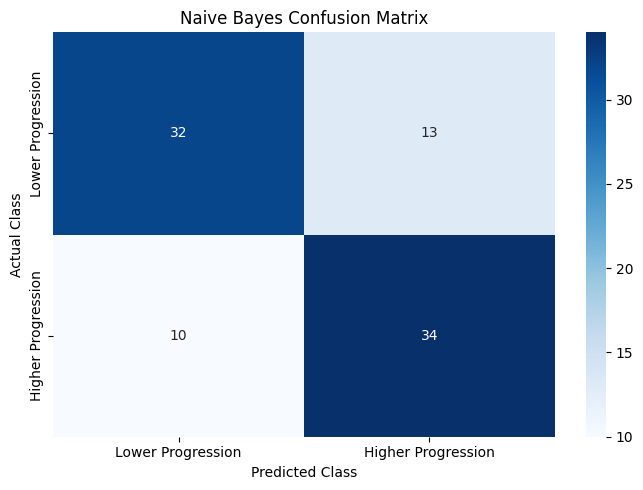

In [ ]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Lower Progression",
        "Higher Progression"
    ],
    yticklabels=[
        "Lower Progression",
        "Higher Progression"
    ]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Naive Bayes Confusion Matrix")

plt.tight_layout()
plt.show()

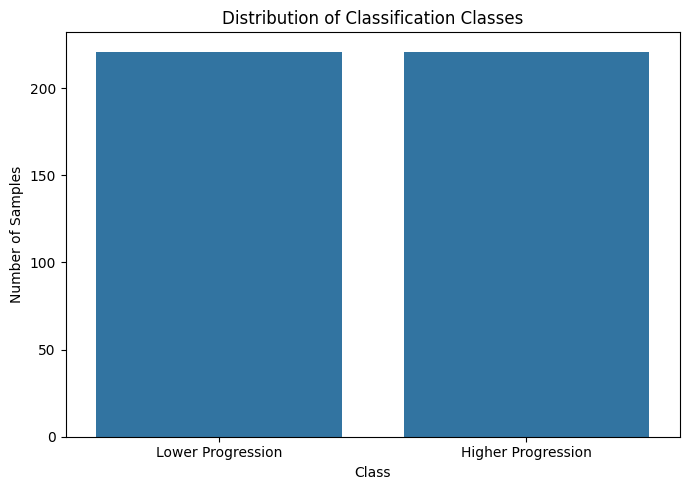

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="class"
)

plt.xticks(
    [0, 1],
    ["Lower Progression", "Higher Progression"]
)

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Distribution of Classification Classes")

plt.tight_layout()
plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison["Actual Label"] = comparison["Actual"].map({
    0: "Lower",
    1: "Higher"
})

comparison["Predicted Label"] = comparison["Predicted"].map({
    0: "Lower",
    1: "Higher"
})

display(comparison.head(20))

,Actual,Predicted,Actual Label,Predicted Label
0,1,1,Higher,Higher
1,1,0,Higher,Lower
2,0,0,Lower,Lower
3,1,1,Higher,Higher
4,1,1,Higher,Higher
5,0,1,Lower,Higher
6,0,0,Lower,Lower
7,1,1,Higher,Higher
8,1,1,Higher,Higher
9,0,0,Lower,Lower


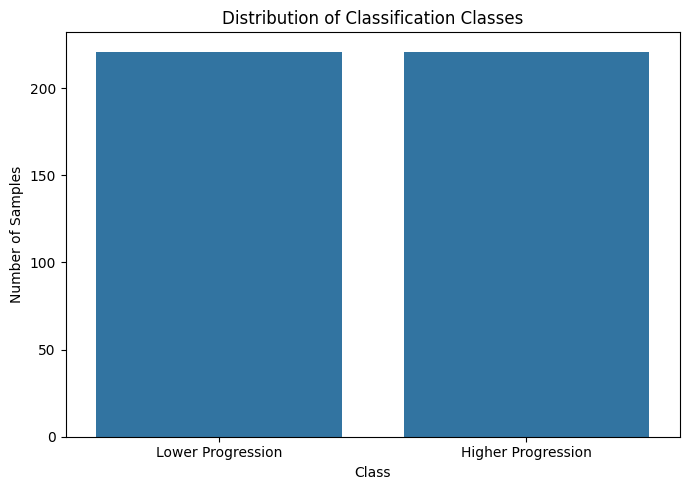

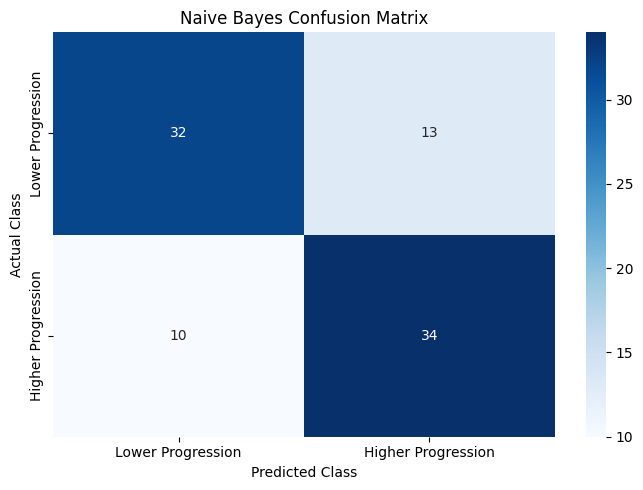

ASSIGNMENT 4 EXPORT COMPLETED
✓ 01_class_distribution.png
✓ 02_confusion_matrix.png
✓ 03_results_and_observations.txt
✓ 04_Naive_Bayes_Complete_Report.html
✓ classification_report.csv
✓ confusion_matrix.csv
✓ diabetes_classification_dataset.csv
✓ predictions.csv

ZIP file: /content/Assignment_4_Complete_Results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# ASSIGNMENT 4 - EXPORT ALL RESULTS
# ============================================================

import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

folder = "Assignment_4_Complete_Results"

# Remove old folder if it exists
if os.path.exists(folder):
    shutil.rmtree(folder)

os.makedirs(folder)

# ------------------------------------------------------------
# 1. Save dataset with classification target
# ------------------------------------------------------------

df.to_csv(
    f"{folder}/diabetes_classification_dataset.csv",
    index=False
)

# ------------------------------------------------------------
# 2. Save predictions
# ------------------------------------------------------------

prediction_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

prediction_results.to_csv(
    f"{folder}/predictions.csv",
    index=False
)

# ------------------------------------------------------------
# 3. Calculate metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

report_dict = classification_report(
    y_test,
    y_pred,
    target_names=[
        "Lower Progression",
        "Higher Progression"
    ],
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

report_df.to_csv(
    f"{folder}/classification_report.csv"
)

# ------------------------------------------------------------
# 4. Save confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Lower", "Actual Higher"],
    columns=["Predicted Lower", "Predicted Higher"]
)

cm_df.to_csv(
    f"{folder}/confusion_matrix.csv"
)

# ------------------------------------------------------------
# 5. Graph - Class Distribution
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="class"
)

plt.xticks(
    [0, 1],
    ["Lower Progression", "Higher Progression"]
)

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Distribution of Classification Classes")

plt.tight_layout()

plt.savefig(
    f"{folder}/01_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ------------------------------------------------------------
# 6. Graph - Confusion Matrix
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Lower Progression",
        "Higher Progression"
    ],
    yticklabels=[
        "Lower Progression",
        "Higher Progression"
    ]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Naive Bayes Confusion Matrix")

plt.tight_layout()

plt.savefig(
    f"{folder}/02_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ------------------------------------------------------------
# 7. Save observations
# ------------------------------------------------------------

observations = f"""
============================================================
ASSIGNMENT 4
NAIVE BAYES CLASSIFICATION
============================================================

Dataset:
Scikit-learn Diabetes Dataset

Number of samples:
{df.shape[0]}

Number of independent features:
{X.shape[1]}

Classification method:
Gaussian Naive Bayes

Train-test split:
80% training / 20% testing

Median target used as classification threshold:
{median_target:.4f}

============================================================
RESULTS
============================================================

Accuracy:
{accuracy:.4f}

Accuracy (%):
{accuracy * 100:.2f}%

Classification Report:
{classification_report(
    y_test,
    y_pred,
    target_names=[
        "Lower Progression",
        "Higher Progression"
    ]
)}

============================================================
OBSERVATIONS
============================================================

1. The continuous target was converted into two classes
   using the median target value.

2. Gaussian Naive Bayes was trained using the 10 independent
   features.

3. The dataset was divided into training and testing sets
   using an 80:20 ratio.

4. The model classified the test samples into lower and
   higher progression categories.

5. Accuracy, precision, recall and F1-score were used to
   evaluate the model.

6. The confusion matrix was used to analyze correct and
   incorrect classifications.

============================================================
CONCLUSION
============================================================

Gaussian Naive Bayes was successfully implemented for
binary classification of the Diabetes dataset. The model
was evaluated using multiple classification metrics and
a confusion matrix.

============================================================
"""

with open(
    f"{folder}/03_results_and_observations.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(observations)

# ------------------------------------------------------------
# 8. Create HTML report
# ------------------------------------------------------------

html = f"""
<html>

<head>

<title>Assignment 4 - Naive Bayes Results</title>

<style>

body {{
    font-family: Arial;
    margin: 40px;
}}

img {{
    width: 700px;
    max-width: 100%;
    margin-bottom: 30px;
}}

table {{
    border-collapse: collapse;
    width: 100%;
}}

th, td {{
    border: 1px solid #999;
    padding: 8px;
}}

th {{
    background-color: #eee;
}}

</style>

</head>

<body>

<h1>Assignment 4: Naive Bayes Classification</h1>

<h2>Dataset</h2>

<p>Scikit-learn Diabetes Dataset</p>

<p>Samples: {df.shape[0]}</p>

<p>Independent Features: {X.shape[1]}</p>

<p>Classification Algorithm: Gaussian Naive Bayes</p>

<p>Training/Test Split: 80/20</p>

<h2>Results</h2>

<p>
Accuracy:
<b>{accuracy * 100:.2f}%</b>
</p>

<h2>Class Distribution</h2>

<img src="01_class_distribution.png">

<h2>Confusion Matrix</h2>

<img src="02_confusion_matrix.png">

<h2>Classification Report</h2>

{report_df.to_html()}

<h2>Conclusion</h2>

<p>
Gaussian Naive Bayes was successfully implemented for
binary classification of the Diabetes dataset. The
continuous target was converted into two classes using
the median value, and the model was evaluated using
accuracy, precision, recall, F1-score and a confusion matrix.
</p>

</body>

</html>
"""

with open(
    f"{folder}/04_Naive_Bayes_Complete_Report.html",
    "w",
    encoding="utf-8"
) as f:
    f.write(html)

# ------------------------------------------------------------
# 9. Create ZIP
# ------------------------------------------------------------

zip_path = shutil.make_archive(
    "Assignment_4_Complete_Results",
    "zip",
    folder
)

# ------------------------------------------------------------
# 10. Display files
# ------------------------------------------------------------

print("=" * 60)
print("ASSIGNMENT 4 EXPORT COMPLETED")
print("=" * 60)

for filename in sorted(os.listdir(folder)):
    print("✓", filename)

print("\nZIP file:", zip_path)

# Download everything
files.download(zip_path)